In [73]:
from pathlib import Path
import importlib
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Reload local analysis modules so rerunning this notebook in a long-lived
# kernel uses the current function signatures rather than cached imports.
import pmt.preprocessing as _pmt_preprocessing
import pmt.selection as _pmt_selection
import pmt.io as _pmt_io
import pmt.provenance as _pmt_provenance
importlib.reload(_pmt_preprocessing)
importlib.reload(_pmt_selection)
importlib.reload(_pmt_io)
importlib.reload(_pmt_provenance)

from pmt.io import *
from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
from pmt.provenance import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Single-voltage selection

Edit the next cell to choose one acquisition and tune its preprocessing and
selection parameters. The settings mirror `Batch_analysis.ipynb`, but this
notebook processes only the selected voltage. Run it before `Fit.ipynb` after
changing baseline, integration-window, or peak-detection settings.


In [74]:
# ======================== STANDALONE CONFIGURATION ========================
# Batch_analysis.ipynb supplies batch_* values automatically. When running this
# notebook directly, edit the values in the `else` block below.
running_from_batch = all(
    name in globals() for name in ("batch_file_name", "batch_data_dir")
)

if running_from_batch:
    file_name = batch_file_name
    data_dir = Path(batch_data_dir)
    channel = globals().get("batch_channel", "Channel 3")
    selection_output_dir = Path(batch_selection_output_dir)
    fit_inputs_path = Path(batch_fit_inputs_dir)
    save_plots = bool(globals().get("batch_save_plots", False))
    baseline_reference_spec = globals().get("batch_baseline_reference_path", None)

    max_files = None
    chunk_size = 128
    waveform_sample_size = 1000
    baseline_window_ns = (0.0, 20.0)
    led_time_ns, pre_led_ns, post_led_ns = 36.0, 20.0, 80.0
    peak_snr_threshold = float(globals().get("batch_peak_snr_threshold", 5.0))
    peak_prominence_snr = globals().get("batch_peak_prominence_snr", None)
    peak_distance_samples = globals().get("batch_peak_distance_samples", None)
    peak_width_samples = globals().get("batch_peak_width_samples", None)
    baseline_rms_max_quantile = globals().get("batch_baseline_rms_max_quantile", 0.95)
    require_clean_baseline = bool(globals().get("batch_require_clean_baseline", False))
    baseline_clean_snr = float(globals().get("batch_baseline_clean_snr", 8.0))
    skip_corrupt_files = bool(globals().get("batch_skip_corrupt_files", True))

    cut_thresholds_snr = list(globals().get("batch_cut_thresholds_snr", [15.0]))
    selection_mode = globals().get("batch_selection_mode", "standard")
    timing_reference_snr = float(globals().get("batch_timing_reference_snr", 15.0))
    peak_timing_tolerance_ns = float(globals().get("batch_peak_timing_tolerance_ns", 5.0))
    timing_reference_requires_single_peak = bool(globals().get(
        "batch_timing_reference_requires_single_peak", selection_mode == "standard"
    ))
    max_allowed_peaks = int(globals().get("batch_max_allowed_peaks", 6))
    include_no_peak_cuts = bool(globals().get("batch_include_no_peak_cuts", True))
    include_shape_cut = bool(globals().get("batch_include_shape_cut", False))
    min_shape_reference_pulses = int(globals().get("batch_min_shape_reference_pulses", 100))
    shape_quantiles = tuple(globals().get("batch_shape_quantiles", (0.01, 0.99)))
    selection_names = globals().get("batch_selection_names", None)
    signal_classification_reference_snr = float(globals().get(
        "batch_signal_classification_reference_snr", 15.0
    ))
    signal_classification_shape_quantiles = tuple(globals().get(
        "batch_signal_classification_shape_quantiles", (0.01, 0.99)
    ))
    signal_classification_generic_shape_ranges = dict(globals().get(
        "batch_signal_classification_generic_shape_ranges", {
            "peak_width_ns": (6.0, 18.0),
            "rise_time_10_90_ns": (2.0, 10.0),
            "fall_time_90_10_ns": (7.0, 38.0),
        },
    ))
    signal_classification_timing_quantiles = tuple(globals().get(
        "batch_signal_classification_timing_quantiles", (0.01, 0.99)
    ))
    signal_classification_min_reference_pulses = int(globals().get(
        "batch_signal_classification_min_reference_pulses", 100
    ))
    signal_classification_max_additional_peak_fraction = float(globals().get(
        "batch_signal_classification_max_additional_peak_fraction", 0.75
    ))

    enable_fixed_pulse_window_charge = bool(globals().get(
        "batch_enable_fixed_pulse_window_charge", selection_mode == "dark_counts"
    ))
    fixed_pulse_window_reference_snr = float(globals().get(
        "batch_fixed_pulse_window_reference_snr", 15.0
    ))
    fixed_pulse_window_width_quantile = float(globals().get(
        "batch_fixed_pulse_window_width_quantile", 0.95
    ))
    fixed_pulse_window_min_reference_pulses = int(globals().get(
        "batch_fixed_pulse_window_min_reference_pulses", 100
    ))
    fixed_pulse_window_read_chunk_size = int(globals().get(
        "batch_fixed_pulse_window_read_chunk_size", 128
    ))
else:
    # Dataset and acquisition. Keep analysis_dir paired with data_dir so the fit
    # notebook cannot accidentally pick up the old repository-level fit_data cache.
    data_dir = Path("PMT_Data/Dark_Counts/trig20_16_8")
    analysis_dir = Path("plots/dark_counts")
    file_name = "WA0089_1000V_Dark_20microV_trig"
    channel = "Channel 3"
    selection_output_dir = analysis_dir / "selection"
    fit_inputs_path = analysis_dir / "fit_data" / "16_8"
    save_plots = False
    baseline_reference_spec = None  # or Path("baseline_reference/dark_counts")

    # Reading and preprocessing. Set max_files to a small integer for quick tests.
    max_files = None
    chunk_size = 128
    waveform_sample_size = 1000
    baseline_window_ns = (0.0, 20.0)
    led_time_ns, pre_led_ns, post_led_ns = 36.0, 20.0, 80.0
    peak_snr_threshold = 8.0
    peak_prominence_snr = 6.0
    peak_distance_samples = 1024
    peak_width_samples = (257, None)  # minimum only; no upper-width rejection
    baseline_rms_max_quantile = 0.95  # keep all nonsaturated waveforms regardless of baseline RMS
    require_clean_baseline = True
    baseline_clean_snr = 8.0
    skip_corrupt_files = True

    # Calibration selection. Modes: standard, timing_only,
    # loose_peak_multiplicity, or dark_counts.
    cut_thresholds_snr = [15.0,20.0,30.0]
    selection_mode = "dark_counts"
    timing_reference_snr = 15.0
    peak_timing_tolerance_ns = 5.0
    timing_reference_requires_single_peak = True
    max_allowed_peaks = 6
    include_no_peak_cuts = True
    include_shape_cut = False
    min_shape_reference_pulses = 100
    shape_quantiles = (0.01, 0.99)
    selection_names = None  # e.g. ["dark_count_quality_above_snr15"]

    # Learn pulse-shape and trigger-time bounds from high-SNR single peaks.
    signal_classification_reference_snr = 15.0
    signal_classification_shape_quantiles = (0.01, 0.99)
    signal_classification_generic_shape_ranges = {
        "peak_width_ns": (6.0, 25.0),
        "rise_time_10_90_ns": (2.0, 10.0),
        "fall_time_90_10_ns": (7.0, 38.0),
    }
    signal_classification_timing_quantiles = (0.01, 0.99)
    signal_classification_min_reference_pulses = 100
    signal_classification_max_additional_peak_fraction = 0.5

    # Learn one trigger-relative window from high-SNR single dark pulses,
    # then apply those exact bounds to every event, including pedestals.
    enable_fixed_pulse_window_charge = True
    fixed_pulse_window_reference_snr = 15.0
    fixed_pulse_window_width_quantile = 0.95
    fixed_pulse_window_min_reference_pulses = 100
    fixed_pulse_window_read_chunk_size = 128

selection_output_dir.mkdir(parents=True, exist_ok=True)
fit_inputs_path.mkdir(parents=True, exist_ok=True)
save_dir = str(selection_output_dir)
file_nickname = file_name
files = find_pmt_files(data_dir, file_name, max_files=max_files)
if not files:
    raise FileNotFoundError(
        f"No files matched {data_dir / (file_name + '-*.h5')}. "
        "Check data_dir and file_name in the configuration cell."
    )

print(f"Acquisition: {file_name}")
print(f"Raw data: {data_dir.resolve()}")
print(f"HDF5 segments: {len(files)}")
print(f"Cached dataframe: {(fit_inputs_path / (file_name + '_df.pkl')).resolve()}")
print(f"Selection mode / SNR cuts: {selection_mode} / {cut_thresholds_snr}")


Acquisition: WA0089_1000V_Dark_20microV_trig
Raw data: /home/aviv/projects/TAU_Neutrino_Lab/PMT-characterization/PMT_calibration/PMT_Data/Dark_Counts/trig20_16_8
HDF5 segments: 1
Cached dataframe: /home/aviv/projects/TAU_Neutrino_Lab/PMT-characterization/PMT_calibration/plots/dark_counts/fit_data/16_8/WA0089_1000V_Dark_20microV_trig_df.pkl
Selection mode / SNR cuts: dark_counts / [15.0, 20.0, 30.0]


In [75]:
# Resolve an optional fixed or voltage-specific median baseline reference.
baseline_reference_path = resolve_baseline_reference_path(
    baseline_reference_spec, file_name
)
baseline_reference_time_ns = None
baseline_reference_mV = None
if baseline_reference_path is not None:
    reference_data = load_baseline_reference(baseline_reference_path)
    baseline_reference_time_ns = reference_data["time_ns"]
    baseline_reference_mV = reference_data["baseline_template_mV"]
    print(f"Using median baseline reference from {baseline_reference_path}")
else:
    print("Using per-event baseline subtraction without a median reference.")


Using per-event baseline subtraction without a median reference.


# Load the pre-cut event dataframe

The streaming loader rejects saturation, optionally rejects contaminated raw
baseline windows, subtracts the configured baseline, computes waveform features,
and retains only a small waveform sample for diagnostic plots. When the learned
fixed charge window is enabled, retained events are reread in bounded chunks so
the same trigger-relative bounds are integrated for pulses and pedestals. After the
selection is built, the **pre-cut** dataframe is cached with the complete
preprocessing and selection manifest that `Fit.ipynb` must use.


In [76]:
# Release large tables, waveform aliases, and figures from an earlier run.
plt.close("all")
for _large_name in (
    "df_sel", "df_waveforms", "waveforms_sample",
    "fixed_window_charges", "selection_analysis",
    "selected_dfs", "selection_cutflows",
    "selection_rejected_masks", "df_selected",
    "df_waveforms_selected", "waveforms_selected",
    "baseline_region", "psds", "psd",
    "t", "wfs", "df",
):
    globals().pop(_large_name, None)
gc.collect()

time_ns, df_sel, waveforms_sample = load_files_streaming(
    files,
    channel=channel,
    chunk_size=chunk_size,
    baseline_window_ns=baseline_window_ns,
    led_time_ns=led_time_ns,
    pre_led_ns=pre_led_ns,
    post_led_ns=post_led_ns,
    peak_snr_threshold=peak_snr_threshold,
    peak_prominence_snr=peak_prominence_snr,
    peak_distance_samples=peak_distance_samples,
    peak_width_samples=peak_width_samples,
    baseline_rms_max_quantile=baseline_rms_max_quantile,
    require_clean_baseline=require_clean_baseline,
    baseline_clean_snr=baseline_clean_snr,
    baseline_reference_time_ns=baseline_reference_time_ns,
    baseline_reference_mV=baseline_reference_mV,
    skip_corrupt_files=skip_corrupt_files,
    keep_waveform_sample=waveform_sample_size,
)
if df_sel.empty:
    raise ValueError("No events remain after preprocessing.")
baseline_rms_quantile_cut = df_sel.attrs["baseline_rms_quantile_cut"]

# The streaming loader keeps sampled waveforms in dataframe order.
df_waveforms = df_sel.iloc[:len(waveforms_sample)].copy()

requested_led_window_ns = (led_time_ns - pre_led_ns, led_time_ns + post_led_ns)
recorded_led_window_ns = (
    max(time_ns[0], requested_led_window_ns[0]),
    min(time_ns[-1], requested_led_window_ns[1]),
)
led_window_coverage = float(df_sel["charge_led_window_coverage"].iloc[0])
print(f"Requested LED charge window: {requested_led_window_ns} ns")
print(f"Recorded part of LED window: {recorded_led_window_ns} ns")
print(f"LED-window coverage: {100 * led_window_coverage:.1f}%")

fixed_pulse_window_charge = {
    "enabled": enable_fixed_pulse_window_charge,
    "column": "charge_fixed_pulse_window_mV_ns",
    "reference_snr": fixed_pulse_window_reference_snr,
    "width_quantile": fixed_pulse_window_width_quantile,
    "min_reference_pulses": fixed_pulse_window_min_reference_pulses,
    "read_chunk_size": fixed_pulse_window_read_chunk_size,
    "reference_pulses": 0,
    "center_ns": None,
    "width_ns": None,
    "window_ns": None,
    "reference_containment_fraction": None,
}
if enable_fixed_pulse_window_charge:
    learned_window = learn_fixed_pulse_charge_window(
        df_sel,
        reference_snr=fixed_pulse_window_reference_snr,
        width_quantile=fixed_pulse_window_width_quantile,
        min_reference_pulses=fixed_pulse_window_min_reference_pulses,
        generic_shape_ranges=signal_classification_generic_shape_ranges,
        max_additional_peak_fraction=(
            signal_classification_max_additional_peak_fraction
        ),
    )
    fixed_pulse_window_charge.update(learned_window)
    fixed_window_ns = tuple(fixed_pulse_window_charge["window_ns"])
    print(
        f"Learned fixed pulse charge window {fixed_window_ns} ns from "
        f"{fixed_pulse_window_charge['reference_pulses']:,} high-SNR "
        f"single pulses (duration quantile="
        f"{fixed_pulse_window_width_quantile:g})."
    )
    print(
        f"Reference-pulse containment: "
        f"{100 * fixed_pulse_window_charge['reference_containment_fraction']:.1f}%"
    )
    print("Rereading retained events to integrate the common fixed window...")
    _, fixed_window_charges = integrate_event_fixed_window_charge(
        df_sel,
        window_ns=fixed_window_ns,
        channel=channel,
        baseline_window_ns=baseline_window_ns,
        baseline_reference_time_ns=baseline_reference_time_ns,
        baseline_reference_mV=baseline_reference_mV,
        read_chunk_size=fixed_pulse_window_read_chunk_size,
    )
    df_sel[fixed_pulse_window_charge["column"]] = fixed_window_charges


Learning baseline-window RMS cutoff at quantile 0.95...
Learned baseline RMS threshold: 0.167617 mV from 29,978 non-saturated waveforms (5.7 s).
Loading: 1/1 files started, 5,120 events processed, 4,855 kept (10 s elapsed)
Loading: 1/1 files started, 22,528 events processed, 21,393 kept (20 s elapsed)
Loading complete: 1/1 files, 30,000 events in 24.9 s
Initial events: 30000
After saturation cut: 29978
After baseline RMS quantile cut (<= 0.167617 mV, q=0.95): 28479
After raw baseline-cleanliness cut (< 8 robust RMS): 28478
After baseline-pulse cut: 28478
Requested LED charge window: (16.0, 116.0) ns
Recorded part of LED window: (16.0, np.float64(100.0)) ns
LED-window coverage: 84.0%
Learned fixed pulse charge window (46.499755621196954, 77.34428019105485) ns from 27,762 high-SNR single pulses (duration quantile=0.95).
Reference-pulse containment: 85.6%
Rereading retained events to integrate the common fixed window...
Fixed-window integration complete: 28,478 retained events from 1 file

In [77]:
df_sel.columns

Index(['peak_idx', 'peak_time_ns', 'peak_amplitude_mV', 'area_mV_ns',
       'charge_peak_window_mV_ns', 'peak_width_ns', 'rise_time_10_90_ns',
       'fall_time_90_10_ns', 'cfd10_rise_ns', 'cfd20_rise_ns', 'cfd30_rise_ns',
       'cfd50_rise_ns', 'cfd90_rise_ns', 'cfd10_fall_ns', 'cfd20_fall_ns',
       'cfd30_fall_ns', 'cfd50_fall_ns', 'cfd90_fall_ns',
       'charge_cfd10_window_mV_ns', 'charge_cfd20_window_mV_ns',
       'charge_cfd30_window_mV_ns', 'charge_cfd50_window_mV_ns',
       'charge_cfd90_window_mV_ns', 'n_peaks', 'second_peak_time_ns',
       'second_peak_amplitude_mV', 'peak_separation_ns', 'n_signal_like_peaks',
       'largest_additional_signal_like_peak_idx',
       'largest_additional_signal_like_peak_amplitude_mV',
       'largest_additional_signal_like_peak_fraction',
       'largest_additional_signal_like_peak_time_ns', 'signal_like_bad_shape',
       'max_excursion_time_ns', 'max_excursion_amplitude_mV',
       'charge_led_window_mV_ns', 'charge_led_window_cover

# Some plots

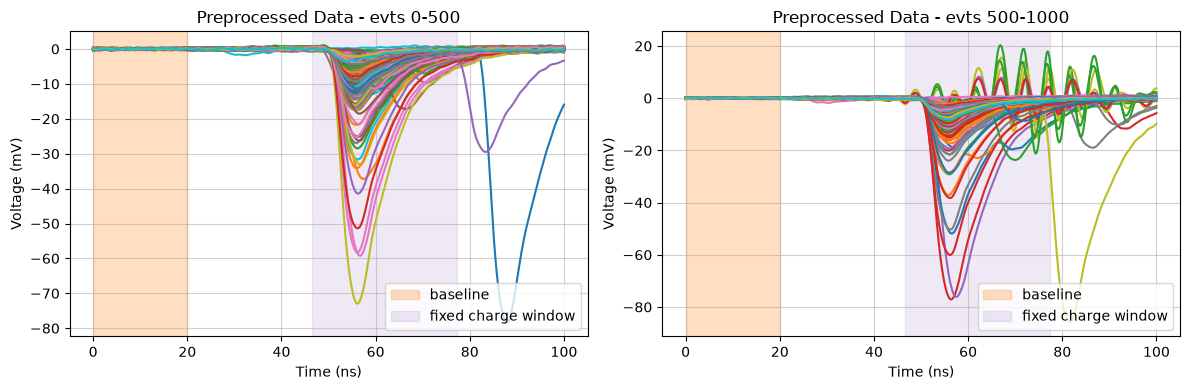

In [78]:
n_to_plot = 500

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, waveforms_sample[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
if fixed_pulse_window_charge["enabled"]:
    axes[0].axvspan(*fixed_pulse_window_charge["window_ns"], color="tab:purple", alpha=0.15, label="fixed charge window")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, waveforms_sample[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
if fixed_pulse_window_charge["enabled"]:
    axes[1].axvspan(*fixed_pulse_window_charge["window_ns"], color="tab:purple", alpha=0.15, label="fixed charge window")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

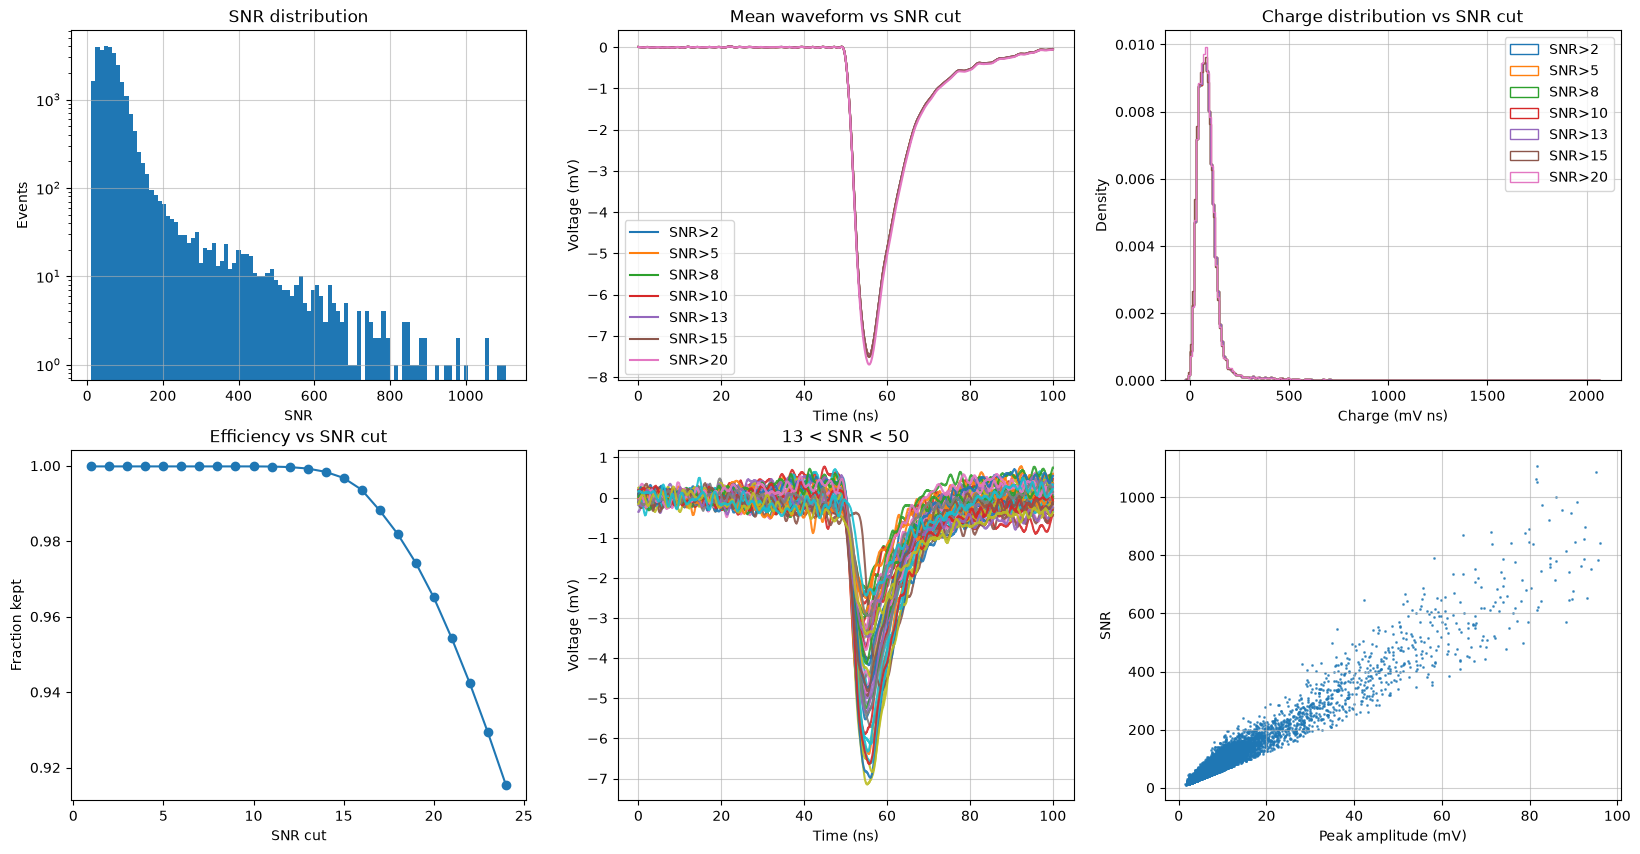

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df_sel)
plot_mean_waveforms_vs_snr(axes[1], df_waveforms, waveforms_sample, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df_sel, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df_sel, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range(axes[4], df_waveforms, waveforms_sample, time_ns, snr_min=13, snr_max=50, n_waveforms=50)
plot_snr_vs_amplitude(axes[5], df_sel)  
save_plot(fig, save_plots, save_dir, file_nickname, f"snr_repport",  Nevents=None);

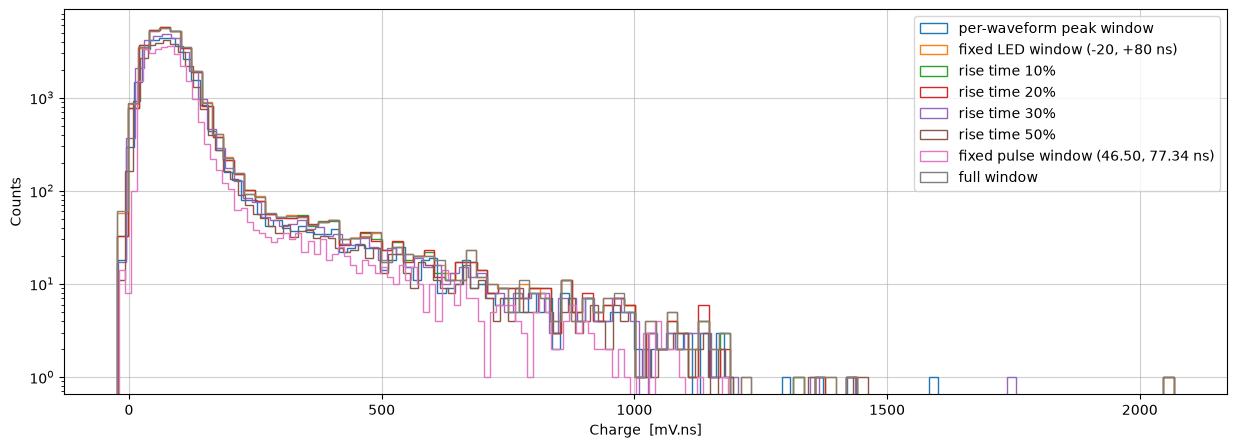

In [80]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="per-waveform peak window");
axes.hist(df_sel.charge_led_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="fixed LED window (-20, +80 ns)");
axes.hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
if fixed_pulse_window_charge["enabled"]:
    fixed_start_ns, fixed_stop_ns = fixed_pulse_window_charge["window_ns"]
    axes.hist(
        df_sel[fixed_pulse_window_charge["column"]], bins=100, range=rg,
        density=den, histtype='step',
        label=f"fixed pulse window ({fixed_start_ns:.2f}, {fixed_stop_ns:.2f} ns)",
    )
axes.hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.set_xlabel('Charge  [mV.ns]');
axes.set_ylabel('Counts');
axes.legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None);



# Baseline Study

In [81]:
from scipy import stats
from scipy.stats import norm
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.signal import welch

In [82]:
t, wfs, df = time_ns, waveforms_sample, df_sel

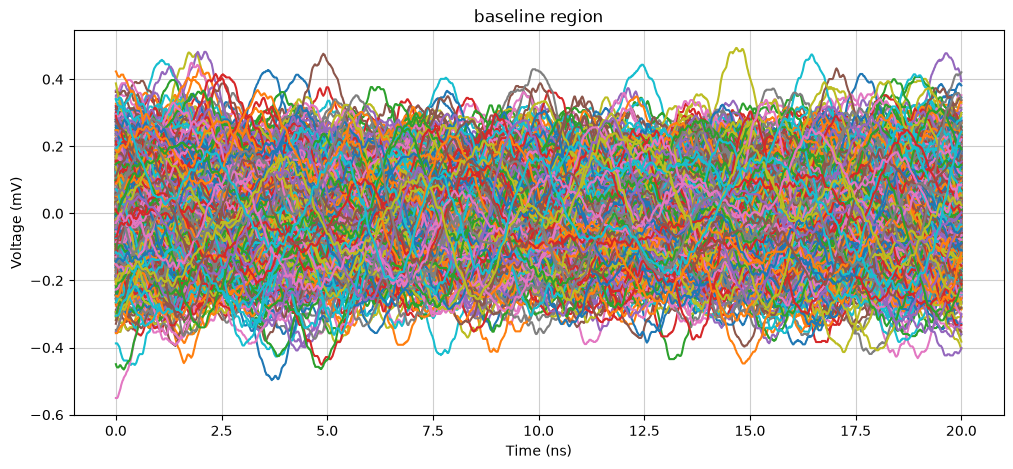

In [83]:
mask = (t >= baseline_window_ns[0]) & (t <= baseline_window_ns[1])
baseline_region = wfs[:, mask]
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
add_plot_waveforms(axes, t[mask], baseline_region[:5000], title='baseline region')
save_plot(fig, save_plots, save_dir, file_nickname, f"Baseline",  Nevents=5000);

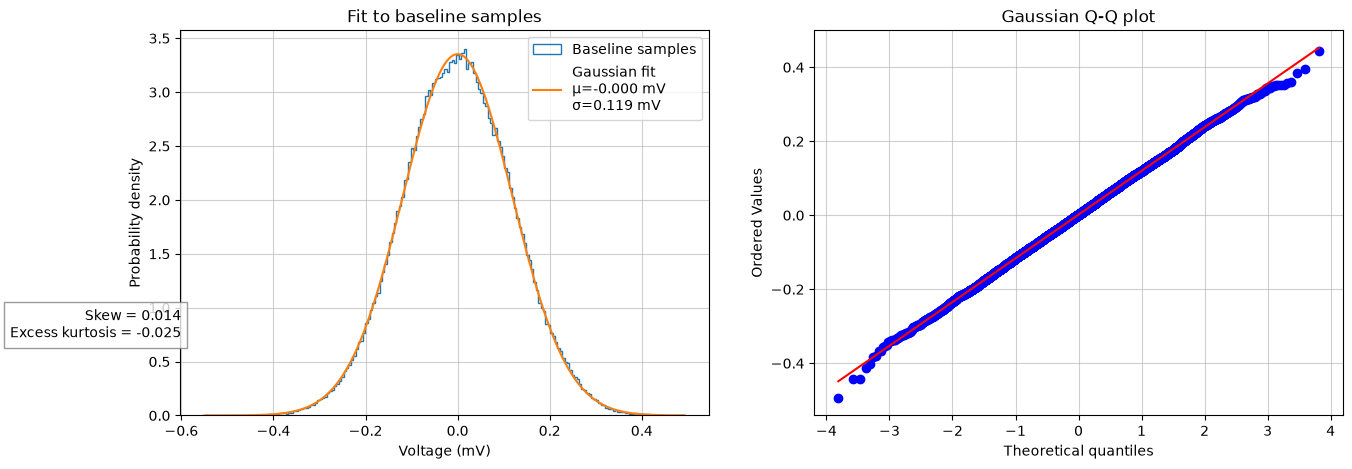

In [84]:
samples = baseline_region.ravel()
mu, sigma = norm.fit(samples)
sk = skew(samples)
kurt = kurtosis(samples)

stats_text = ( f"Skew = {sk:.3f}\n" f"Excess kurtosis = {kurt:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

x = np.linspace(samples.min(), samples.max(), 500)
axes[0].hist(samples, bins=200, density=True, histtype='step', label='Baseline samples')
axes[0].plot(x, norm.pdf(x, mu, sigma), label=f'Gaussian fit\nμ={mu:.3f} mV\nσ={sigma:.3f} mV')
axes[0].text( -0.6, 1.0, stats_text, ha='right', va='top',
          bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray') )
axes[0].set_xlabel("Voltage (mV)")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Fit to baseline samples")
axes[0].legend();

rng = np.random.default_rng(42)
idx = rng.choice(len(samples), size=10_000, replace=False)
stats.probplot(samples[idx], dist="norm", plot=plt)
axes[1].set_title("Gaussian Q-Q plot")
save_plot(fig, save_plots, save_dir, file_nickname, f"baseline_fit",  Nevents=None);





Sampling step: 0.01562 ns


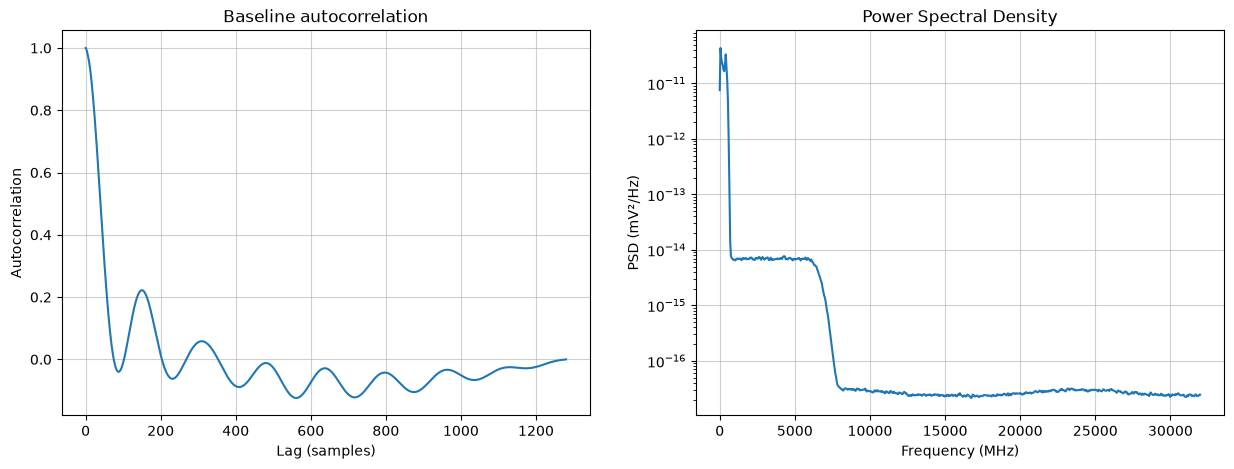

In [85]:
corr = np.zeros(baseline_region.shape[1])
for wf in baseline_region:
    c = correlate(wf, wf, mode='full')
    c = c[c.size//2:]
    corr += c / c[0]          # normalize
corr /= len(baseline_region)
lags = np.arange(len(corr))


dt = np.median(np.diff(t))
print(f"Sampling step: {dt:.5f} ns")
fs = 1 / (dt * 1e-9)          # sampling frequency (Hz)
psds = []
for wf in baseline_region:
    f, Pxx = welch( wf, fs=fs, nperseg=len(wf), detrend='constant')
    psds.append(Pxx)
psd = np.mean(psds, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

axes[0].plot(lags, corr)
axes[0].set_title("Baseline autocorrelation")
axes[0].set_xlabel("Lag (samples)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True);

axes[1].semilogy(f/1e6, psd)
axes[1].set_title("Power Spectral Density")
axes[1].set_xlabel("Frequency (MHz)")
axes[1].set_ylabel("PSD (mV²/Hz)")
axes[1].grid(True)

save_plot(fig, save_plots, save_dir, file_nickname, f"autocorrelation",  Nevents=None);

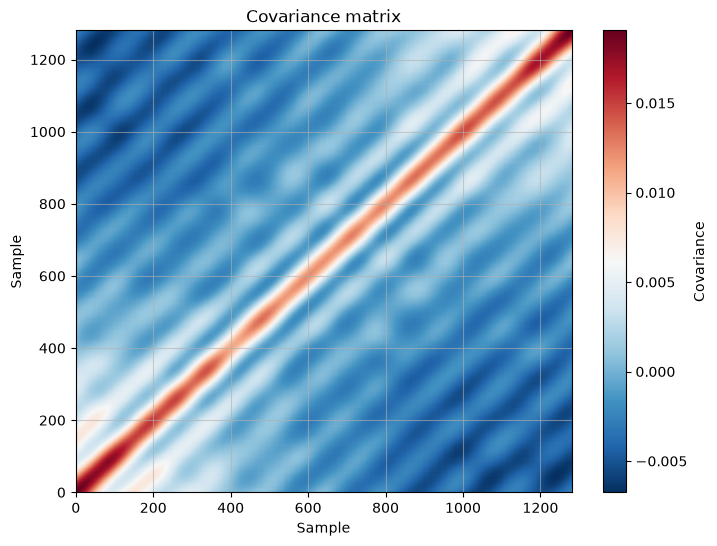

In [86]:
C = np.cov(baseline_region.T)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))

plt.imshow(C,
           origin='lower',
           cmap='RdBu_r',
           aspect='auto')
plt.colorbar(label="Covariance")
plt.title("Covariance matrix")
plt.xlabel("Sample")
plt.ylabel("Sample")

save_plot(fig, save_plots, save_dir, file_nickname, f"covariance_matrix",  Nevents=None);

# Calibration selections

The same selection builder is used here, in `Fit.ipynb`, and by the batch
workflow. Quality requirements are applied only to events at or above each SNR
threshold; lower-SNR and no-peak events remain available to model the pedestal.


In [87]:
df_sel, learned_signal_classification = add_learned_signal_classification(
    df_sel,
    reference_snr=signal_classification_reference_snr,
    shape_quantiles=signal_classification_shape_quantiles,
    timing_quantiles=signal_classification_timing_quantiles,
    min_reference_pulses=signal_classification_min_reference_pulses,
    generic_shape_ranges=signal_classification_generic_shape_ranges,
    max_additional_peak_fraction=(
        signal_classification_max_additional_peak_fraction
    ),
    copy=False,
)
print("Learned signal classification:")
print(f"  reference pulses: {learned_signal_classification['reference_pulses']:,}")
print(f"  generic shape ranges: {learned_signal_classification['generic_shape_ranges']}")
print(
    "  max additional/main candidate amplitude fraction: "
    f"{learned_signal_classification['max_additional_peak_fraction']:.3g}"
)
print(f"  shape ranges: {learned_signal_classification['shape_ranges']}")
print(f"  timing range: {learned_signal_classification['timing_range_ns']} ns")
print(f"  counts: {learned_signal_classification['counts']}")

selection_analysis = build_calibration_selections(
    df_sel,
    cut_thresholds_snr=cut_thresholds_snr,
    selection_mode=selection_mode,
    timing_reference_snr=timing_reference_snr,
    peak_timing_tolerance_ns=peak_timing_tolerance_ns,
    timing_reference_requires_single_peak=timing_reference_requires_single_peak,
    max_allowed_peaks=max_allowed_peaks,
    include_no_peak_cuts=include_no_peak_cuts,
    include_shape_cut=include_shape_cut,
    min_shape_reference_pulses=min_shape_reference_pulses,
    shape_quantiles=shape_quantiles,
    selection_names=selection_names,
    materialize_selected_dfs=False,
)

selection_mode = selection_analysis["selection_mode"]
selection_configs = selection_analysis["selection_configs"]
selected_dfs = selection_analysis["selected_dfs"]
selection_cutflows = selection_analysis["cutflows"]
selection_rejected_masks = selection_analysis["rejected_masks"]
uses_led_timing = selection_analysis["uses_led_timing"]
timing_reference = selection_analysis["timing_reference"]
expected_peak_time_ns = selection_analysis["expected_peak_time_ns"]
allowed_peak_window_ns = selection_analysis["allowed_peak_window_ns"]
shape_cut_available = selection_analysis["shape_cut_available"]
shape_cut_ranges = selection_analysis["shape_cut_ranges"]

# The cache is written only after the selection succeeds. Fit.ipynb treats this
# manifest as the sole source of preprocessing and selection settings.
preprocessing_settings = {
    "channel": channel,
    "baseline_window_ns": tuple(baseline_window_ns),
    "led_time_ns": led_time_ns,
    "pre_led_ns": pre_led_ns,
    "post_led_ns": post_led_ns,
    "peak_snr_threshold": peak_snr_threshold,
    "peak_prominence_snr": peak_prominence_snr,
    "peak_distance_samples": peak_distance_samples,
    "peak_width_samples": peak_width_samples,
    "baseline_rms_quantile_cut": baseline_rms_quantile_cut,
    "require_clean_baseline": require_clean_baseline,
    "baseline_clean_snr": baseline_clean_snr,
    "baseline_reference_path": (
        None if baseline_reference_path is None else str(baseline_reference_path.resolve())
    ),
    "skip_corrupt_files": skip_corrupt_files,
    "fixed_pulse_window_charge": fixed_pulse_window_charge,
}
selection_settings = {
    "learned_signal_classification": learned_signal_classification,
    "cut_thresholds_snr": tuple(float(value) for value in cut_thresholds_snr),
    "selection_mode": selection_mode,
    "timing_reference_snr": timing_reference_snr,
    "peak_timing_tolerance_ns": peak_timing_tolerance_ns,
    "timing_reference_requires_single_peak": timing_reference_requires_single_peak,
    "max_allowed_peaks": max_allowed_peaks,
    "include_no_peak_cuts": include_no_peak_cuts,
    "include_shape_cut": include_shape_cut,
    "min_shape_reference_pulses": min_shape_reference_pulses,
    "shape_quantiles": tuple(shape_quantiles),
    "selection_names": (
        None if selection_names is None else tuple(selection_names)
    ),
    "generated_selection_names": tuple(
        config["name"] for config in selection_configs
    ),
}
cache_provenance = build_selection_cache_provenance(
    acquisition=file_name,
    data_dir=data_dir,
    source_files=files,
    preprocessing=preprocessing_settings,
    selection=selection_settings,
)
df_sel.attrs["pmt_selection"] = cache_provenance
for selected_df in selected_dfs.values():
    selected_df.attrs["pmt_selection"] = cache_provenance
df_file = fit_inputs_path / f"{file_nickname}_df.pkl"
df_file_temporary = df_file.with_suffix(df_file.suffix + ".partial")
df_sel.to_pickle(df_file_temporary)
df_file_temporary.replace(df_file)
print(f"Saved {len(df_sel):,} pre-cut events and Selection manifest to {df_file}")

print(f"Selection mode: {selection_mode}")
if uses_led_timing:
    print(f"Expected LED peak time: {expected_peak_time_ns:.2f} ns")
    print(f"Allowed peak window: {allowed_peak_window_ns} ns")
else:
    print("Dark-count mode: LED timing estimation and timing cuts are disabled.")
if include_shape_cut and not shape_cut_available:
    print(
        f"Pulse-shape cut requested but skipped: fewer than "
        f"{min_shape_reference_pulses} reference pulses."
    )
for column, limits in shape_cut_ranges.items():
    print(f"{column}: {limits[0]:.3g} to {limits[1]:.3g} ns")

for config in selection_configs:
    print(f"\n--- {config['label']} ---")
    selection_cutflows[config["name"]].print()


Learned signal classification:
  reference pulses: 27,762
  generic shape ranges: {'peak_width_ns': (6.0, 25.0), 'rise_time_10_90_ns': (2.0, 10.0), 'fall_time_90_10_ns': (7.0, 38.0)}
  max additional/main candidate amplitude fraction: 0.5
  shape ranges: {'peak_width_ns': (8.708730590427555, 11.938007848369699), 'rise_time_10_90_ns': (2.7833218612980115, 6.201534379045402), 'fall_time_90_10_ns': (9.411688586634384, 29.94361883421316)}
  timing range: (53.859375, 61.06859375) ns
  counts: {'has_pulse_shape': 26323, 'has_generic_pulse_shape': 27850, 'is_trigger_aligned': 27655, 'has_isolated_peak': 28273, 'has_dominant_peak': 28340, 'signal_oscillatory': 5, 'signal_with_small_additional_peaks': 67, 'signal_bad_generic_shape': 494, 'signal_good': 25904, 'signal_noise_like': 2019, 'signal_off_time': 417}
Saved 28,478 pre-cut events and Selection manifest to plots/dark_counts/fit_data/16_8/WA0089_1000V_Dark_20microV_trig_df.pkl
Selection mode: dark_counts
Dark-count mode: LED timing estimat

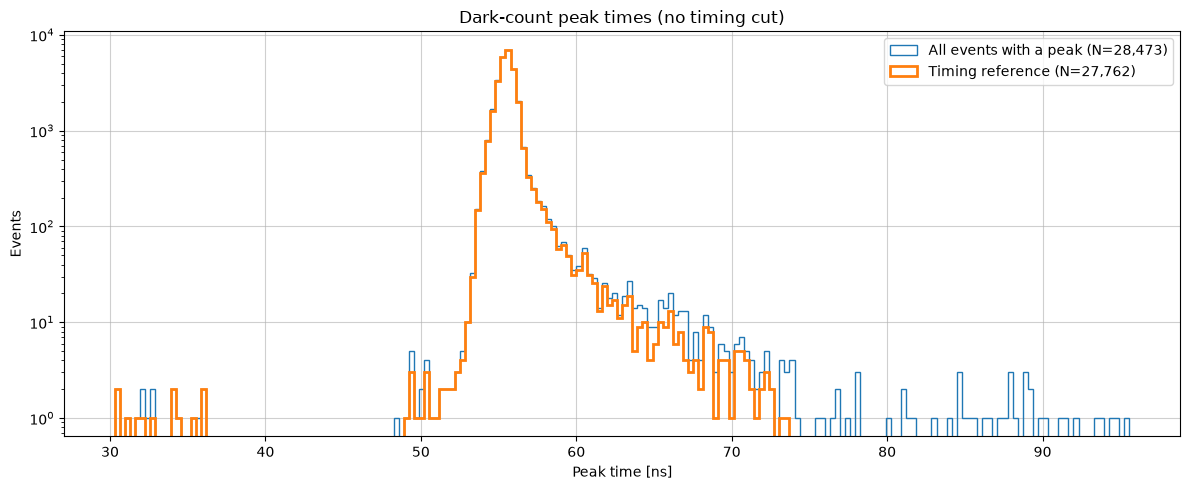

In [88]:
finite_peak_times = df_sel.loc[np.isfinite(df_sel["peak_time_ns"]), "peak_time_ns"]
if finite_peak_times.empty:
    print("No finite peak times are available for the timing diagnostic.")
else:
    timing_min, timing_max = finite_peak_times.min(), finite_peak_times.max()
    if timing_min == timing_max:
        timing_plot_bins = np.array([timing_min - 0.5, timing_min + 0.5])
    else:
        timing_plot_bins = np.linspace(timing_min, timing_max, 201)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(
        finite_peak_times, bins=timing_plot_bins, histtype="step",
        label=f"All events with a peak (N={len(finite_peak_times):,})",
    )
    if not timing_reference.empty:
        ax.hist(
            timing_reference, bins=timing_plot_bins, histtype="step", linewidth=2,
            label=f"Timing reference (N={len(timing_reference):,})",
        )
    if uses_led_timing:
        ax.axvline(expected_peak_time_ns, color="tab:red", label="Expected LED peak")
        ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.2, label="Accepted window")
    ax.set(
        xlabel="Peak time [ns]", ylabel="Events", yscale="log",
        title=("LED timing selection" if uses_led_timing else "Dark-count peak times (no timing cut)"),
    )
    ax.legend()
    fig.tight_layout()
    save_plot(fig, save_plots, save_dir, file_nickname, "peak_timing_selection", Nevents=None)


In [89]:
# Save explicit, self-describing selected caches for inspection or downstream use.
# Fit.ipynb intentionally reloads the pre-cut cache and rebuilds these selections.
# Keep the historical *_df_selected.pkl alias, preferring a quality-cut sample.
default_config = next(
    (config for config in selection_configs if config["name"] != "no_peak_cuts"),
    selection_configs[0],
)
default_selection_name = default_config["name"]
cutflow = selection_cutflows[default_selection_name]

# Materialize and save one selected dataframe at a time. Keeping every SNR
# selection resident simultaneously can multiply RAM use by the number of cuts.
selection_rows = []
df_selected = None
for config in selection_configs:
    name = config["name"]
    selection_mask = selection_cutflows[name].mask
    selected_df = (
        df_sel if np.all(selection_mask)
        else df_sel.loc[selection_mask].copy()
    )
    selected_df.attrs["pmt_selection"] = cache_provenance
    selected_path = fit_inputs_path / f"{file_nickname}_df_selected_{name}.pkl"
    selected_temporary_path = selected_path.with_suffix(
        selected_path.suffix + ".partial"
    )
    selected_df.to_pickle(selected_temporary_path)
    selected_temporary_path.replace(selected_path)
    selection_rows.append({
        "name": name,
        "label": config["label"],
        "events": len(selected_df),
        "fraction": len(selected_df) / len(df_sel),
        "path": str(selected_path),
    })
    if name == default_selection_name:
        df_selected = selected_df
    elif selected_df is not df_sel:
        del selected_df
        gc.collect()
if df_selected is None:
    raise RuntimeError("Default selected dataframe was not materialized")
selected_dfs = {default_selection_name: df_selected}
default_selected_path = fit_inputs_path / f"{file_nickname}_df_selected.pkl"
default_selected_temporary_path = default_selected_path.with_suffix(
    default_selected_path.suffix + ".partial"
)
df_selected.to_pickle(default_selected_temporary_path)
default_selected_temporary_path.replace(default_selected_path)

selection_summary = pd.DataFrame(selection_rows)
display(selection_summary)

if len(waveforms_sample):
    sample_cut_mask = cutflow.mask[:len(waveforms_sample)]
    df_waveforms_selected = df_waveforms.loc[sample_cut_mask].copy()
    waveforms_selected = waveforms_sample[sample_cut_mask]
else:
    df_waveforms_selected = df_waveforms.iloc[0:0].copy()
    waveforms_selected = waveforms_sample


,name,label,events,fraction,path
0,no_peak_cuts,No peak cuts,28478,1.000000,plots/dark_counts/fit_data/16_8/WA0089_1000V_D...
1,dark_count_quality_above_snr15,Dominant single peak (timing ignored) at SNR >...,27854,0.978088,plots/dark_counts/fit_data/16_8/WA0089_1000V_D...
2,dark_count_quality_above_snr20,Dominant single peak (timing ignored) at SNR >...,27916,0.980265,plots/dark_counts/fit_data/16_8/WA0089_1000V_D...
3,dark_count_quality_above_snr30,Dominant single peak (timing ignored) at SNR >...,28128,0.987710,plots/dark_counts/fit_data/16_8/WA0089_1000V_D...


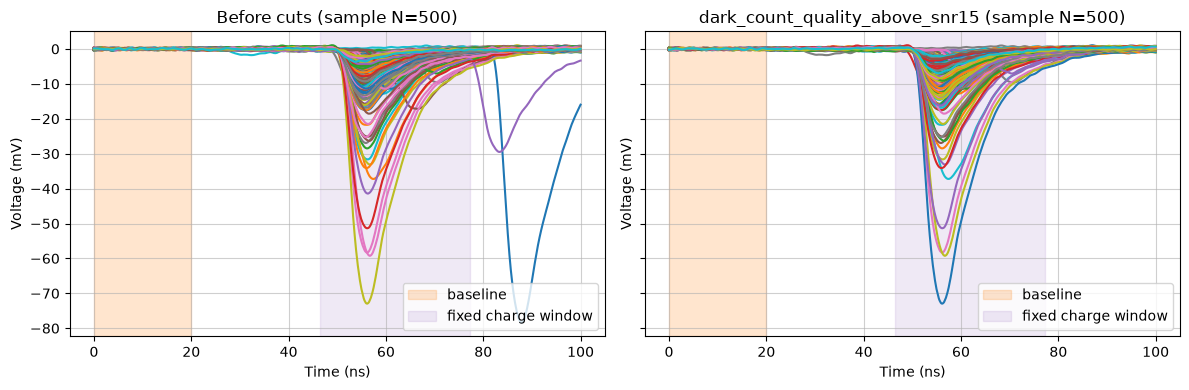

In [90]:
n_to_plot = min(500, len(waveforms_sample))
if n_to_plot == 0:
    print("Waveform sample disabled; skipping before/after selection plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
    add_plot_waveforms(
        axes[0], time_ns, waveforms_sample[:n_to_plot],
        title=f"Before cuts (sample N={n_to_plot})",
    )
    selected_to_plot = waveforms_selected[:n_to_plot]
    add_plot_waveforms(
        axes[1], time_ns, selected_to_plot,
        title=f"{default_selection_name} (sample N={len(selected_to_plot)})",
    )
    for ax in axes:
        ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.2, label="baseline")
        if fixed_pulse_window_charge["enabled"]:
            ax.axvspan(*fixed_pulse_window_charge["window_ns"], color="tab:purple", alpha=0.14, label="fixed charge window")
        if uses_led_timing:
            ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.12, label="accepted peak time")
        ax.legend(loc="lower right")
    fig.tight_layout()
    save_plot(fig, save_plots, save_dir, file_nickname, "waveforms_before_after_selection", Nevents=n_to_plot)
